# Automated Vulnerability Detection in Source Code
### Implementation based on arxiv:2602.23121
**CNN-based vulnerability detection using 91-category tokenization + 8-bit binary encoding**

---
**Pipeline:**
1. Install dependencies
2. Tokenization (91 categories)
3. Binary vector encoding
4. Dataset preparation
5. CNN model definition
6. Training loop
7. Evaluation (Precision-Recall curves)
8. Inference on new code

## 1. Install Dependencies

In [ ]:
!pip install torch torchvision pycparser datasets scikit-learn matplotlib numpy tqdm

## 2. Imports

In [ ]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report,
    roc_auc_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 3. Tokenizer — 91 Token Categories

Categories:
- **0**: UNKNOWN / padding
- **1–30**: C keywords (`int`, `float`, `char`, `void`, `if`, `else`, etc.)
- **31–50**: Operators & punctuation (`+`, `-`, `*`, `/`, `{`, `}`, etc.)
- **51–60**: Special dangerous C functions (`strcpy`, `memcpy`, `gets`, etc.)
- **61**: Generic IDENTIFIER (variable/function names)
- **62**: NUMBER (any numeric literal)
- **63**: STRING LITERAL
- **64–90**: Reserved / extensible

In [ ]:
# ── 91-Category Token Map ──────────────────────────────────────────────────

KEYWORD_TOKENS = {
    'auto': 1, 'break': 2, 'case': 3, 'char': 4,
    'const': 5, 'continue': 6, 'default': 7, 'do': 8,
    'double': 9, 'else': 10, 'enum': 11, 'extern': 12,
    'float': 13, 'for': 14, 'goto': 15, 'if': 16,
    'int': 17, 'long': 18, 'register': 19, 'return': 20,
    'short': 21, 'signed': 22, 'sizeof': 23, 'static': 24,
    'struct': 25, 'switch': 26, 'typedef': 27, 'union': 28,
    'unsigned': 29, 'void': 30, 'volatile': 31, 'while': 32,
    # C99/C11 extensions
    'inline': 33, '_Bool': 34, '_Complex': 35, 'restrict': 36,
    'NULL': 37, 'true': 38, 'false': 39, 'nullptr': 40,
}

OPERATOR_TOKENS = {
    '+': 41, '-': 42, '*': 43, '/': 44, '%': 45,
    '=': 46, '==': 47, '!=': 48, '<': 49, '>': 50,
    '<=': 51, '>=': 52, '&&': 53, '||': 54, '!': 55,
    '&': 56, '|': 57, '^': 58, '~': 59, '<<': 60,
    '>>': 61, '++': 62, '--': 63, '->': 64, '.': 65,
    '{': 66, '}': 67, '(': 68, ')': 69, '[': 70,
    ']': 71, ';': 72, ',': 73, ':': 74, '?': 75,
    '#': 76,
}

# Dangerous C functions — given dedicated token IDs for security signal
DANGEROUS_FUNC_TOKENS = {
    'strcpy': 77, 'strncpy': 78, 'strcat': 79, 'strncat': 80,
    'sprintf': 81, 'snprintf': 82, 'vsprintf': 83,
    'gets': 84, 'fgets': 85,
    'memcpy': 86, 'memmove': 87, 'memset': 88,
    'scanf': 89, 'sscanf': 90,
    # Generic identifiers, numbers, strings mapped below
}

IDENTIFIER_TOKEN = 91   # any variable/function name not in special list (mapped to 91, index 90)
NUMBER_TOKEN     = 92   # any numeric literal
STRING_TOKEN     = 93   # any string literal
UNKNOWN_TOKEN    = 0    # padding / unrecognised

# Total vocab = 93 categories, representable in 7 bits; paper uses 8 bits for future-proofing
VOCAB_SIZE = 94
BIT_WIDTH  = 8


def tokenize_c_code(source: str, max_len: int = 500) -> list:
    """
    Tokenise a C function body into a list of token-category IDs.
    Uses a hand-rolled regex lexer (no C parser needed, handles malformed code).
    """
    # Remove block & line comments
    source = re.sub(r'/\*.*?\*/', ' ', source, flags=re.DOTALL)
    source = re.sub(r'//[^\n]*', ' ', source)

    # Regex patterns in priority order
    token_patterns = [
        ('STRING',   r'"(?:[^"\\]|\\.)*"'),          # string literals
        ('NUMBER',   r'\b(?:0x[0-9a-fA-F]+|\d+\.?\d*(?:[eE][+-]?\d+)?[uUlLfF]*)\b'),
        ('OP2',      r'==|!=|<=|>=|&&|\|\||<<|>>|\+\+|--|->'),  # 2-char ops first
        ('OP1',      r'[+\-*/%=<>!&|^~(){};,\[\]:.?#]'),
        ('WORD',     r'[A-Za-z_][A-Za-z0-9_]*'),      # identifiers / keywords
    ]

    master_pattern = '|'.join(f'(?P<{name}>{pat})' for name, pat in token_patterns)
    compiled = re.compile(master_pattern)

    token_ids = []
    for match in compiled.finditer(source):
        kind = match.lastgroup
        val  = match.group()

        if kind == 'STRING':
            token_ids.append(STRING_TOKEN)
        elif kind == 'NUMBER':
            token_ids.append(NUMBER_TOKEN)
        elif kind in ('OP1', 'OP2'):
            token_ids.append(OPERATOR_TOKENS.get(val, UNKNOWN_TOKEN))
        elif kind == 'WORD':
            if val in KEYWORD_TOKENS:
                token_ids.append(KEYWORD_TOKENS[val])
            elif val in DANGEROUS_FUNC_TOKENS:
                token_ids.append(DANGEROUS_FUNC_TOKENS[val])
            else:
                token_ids.append(IDENTIFIER_TOKEN)

        if len(token_ids) >= max_len:
            break

    # Pad to max_len
    token_ids += [UNKNOWN_TOKEN] * (max_len - len(token_ids))
    return token_ids[:max_len]


def tokens_to_binary_matrix(token_ids: list) -> np.ndarray:
    """
    Convert list of token IDs → (max_len, 8) binary matrix.
    Each token ID encoded as its 8-bit binary representation.
    """
    matrix = np.array(
        [[int(b) for b in format(t, f'0{BIT_WIDTH}b')] for t in token_ids],
        dtype=np.float32
    )
    return matrix  # shape: (max_len, 8)


def encode_function(source: str, max_len: int = 500) -> np.ndarray:
    """Full pipeline: source code → binary matrix ready for CNN."""
    token_ids = tokenize_c_code(source, max_len)
    return tokens_to_binary_matrix(token_ids)


# ── Quick sanity check ──
sample = """
void copy_input(char *dst, char *src) {
    strcpy(dst, src);   // dangerous!
    int x = 42;
    if (x > 0) return;
}
"""
mat = encode_function(sample, max_len=20)
ids = tokenize_c_code(sample, max_len=20)
print('Token IDs (first 15):', ids[:15])
print('Binary matrix shape :', mat.shape)
print('First 3 rows:\n', mat[:3])

Token IDs (first 15): [30, 91, 68, 4, 43, 91, 73, 4, 43, 91, 69, 66, 77, 68, 91]
Binary matrix shape : (20, 8)
First 3 rows:
 [[0. 0. 0. 1. 1. 1. 1. 0.]
 [0. 1. 0. 1. 1. 0. 1. 1.]
 [0. 1. 0. 0. 0. 1. 0. 0.]]


## 4. CWE Label Groups
The paper groups related CWE identifiers into 5 label classes.

In [ ]:
# ── CWE → label group mapping ────────────────────────────────────────────
CWE_LABEL_MAP = {
    # Buffer errors
    'CWE119': 'BUFFER', 'CWE120': 'BUFFER', 'CWE121': 'BUFFER',
    'CWE122': 'BUFFER', 'CWE123': 'BUFFER', 'CWE124': 'BUFFER',
    'CWE125': 'BUFFER', 'CWE126': 'BUFFER', 'CWE127': 'BUFFER',
    'CWE787': 'BUFFER',
    # Null pointer dereference
    'CWE476': 'NULL_DEREF',
    # Format string
    'CWE134': 'FORMAT_STRING',
    # Integer overflow
    'CWE190': 'INTEGER', 'CWE191': 'INTEGER', 'CWE197': 'INTEGER',
    # Use after free / memory
    'CWE416': 'MEMORY', 'CWE415': 'MEMORY', 'CWE401': 'MEMORY',
}

LABEL_NAMES = ['BUFFER', 'NULL_DEREF', 'FORMAT_STRING', 'INTEGER', 'MEMORY']
LABEL2IDX   = {name: i for i, name in enumerate(LABEL_NAMES)}
NUM_CLASSES = len(LABEL_NAMES)


def cwe_list_to_multihot(cwe_list: list) -> np.ndarray:
    """Convert a list of CWE strings to a multi-hot label vector."""
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    for cwe in cwe_list:
        label = CWE_LABEL_MAP.get(cwe)
        if label:
            vec[LABEL2IDX[label]] = 1.0
    return vec


# Example
print('BUFFER + NULL_DEREF:', cwe_list_to_multihot(['CWE119', 'CWE476']))
print('Clean function:     ', cwe_list_to_multihot([]))

BUFFER + NULL_DEREF: [1. 1. 0. 0. 0.]
Clean function:      [0. 0. 0. 0. 0.]


## 5. Dataset

### Option A — Use Draper VDISC (from HuggingFace, ~1.2M samples)
### Option B — Use synthetic toy data to test the full pipeline right now

Uncomment whichever you want to use.

In [ ]:
# Synthetic toy dataset (runs without downloads)

SYNTHETIC_DATA = [
    # (source_code, [cwe_labels])
    ("void safe(char *buf, int n){int i; for(i=0;i<n;i++) buf[i]=0;}", []),
    ("void vuln(char *dst, char *src){strcpy(dst, src);}", ['CWE120']),
    ("int overflow(int x){return x + 2147483647;}", ['CWE190']),
    ("void fmt_bug(char *s){printf(s);}", ['CWE134']),
    ("int* null_deref(){int *p=NULL; return p+1;}", ['CWE476']),
    ("void heap_buf(char *s){char *d=malloc(4); memcpy(d,s,100);}", ['CWE119','CWE122']),
    ("int safe_add(int a, int b){if(b>0 && a>INT_MAX-b)return -1; return a+b;}", []),
    ("char* uaf(){char *p=malloc(10); free(p); return p;}", ['CWE416']),
    ("void bounded(char *dst, char *src, int n){strncpy(dst,src,n-1); dst[n-1]=0;}", []),
    ("void stack_overflow(char *input){char buf[8]; strcpy(buf,input);}", ['CWE121']),
] * 200  # repeat to get 2000 samples for demo

print(f'Synthetic dataset size: {len(SYNTHETIC_DATA)} samples')

Synthetic dataset size: 2000 samples


In [ ]:
class VulnDataset(Dataset):
    def __init__(self, data, max_len=500):
        """
        data: list of (source_code: str, cwe_list: list)
        """
        self.max_len = max_len
        self.samples = []
        for src, cwes in tqdm(data, desc='Encoding'):
            x = encode_function(src, max_len)        # (max_len, 8)
            y = cwe_list_to_multihot(cwes)           # (NUM_CLASSES,)
            self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x), torch.tensor(y)


# Train / val / test split
import random
random.seed(42)
random.shuffle(SYNTHETIC_DATA)

n = len(SYNTHETIC_DATA)
train_data = SYNTHETIC_DATA[:int(0.7*n)]
val_data   = SYNTHETIC_DATA[int(0.7*n):int(0.85*n)]
test_data  = SYNTHETIC_DATA[int(0.85*n):]

MAX_LEN = 500
train_ds = VulnDataset(train_data, MAX_LEN)
val_ds   = VulnDataset(val_data,   MAX_LEN)
test_ds  = VulnDataset(test_data,  MAX_LEN)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Encoding: 100%|██████████| 300/300 [00:01<00:00, 218.52it/s]

Train: 1400 | Val: 300 | Test: 300


In [ ]:
# ── Balanced sampler: oversample vulnerable functions ──

def make_balanced_sampler(dataset):
    labels = np.array([y.numpy() for _, y in dataset])
    is_vuln = (labels.sum(axis=1) > 0).astype(float)
    n_vuln  = is_vuln.sum()
    n_clean = len(is_vuln) - n_vuln
    weights = np.where(is_vuln, 1.0 / max(n_vuln, 1), 1.0 / max(n_clean, 1))
    return WeightedRandomSampler(weights, num_samples=len(dataset), replacement=True)


train_loader = DataLoader(train_ds, batch_size=32, sampler=make_balanced_sampler(train_ds))
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print('DataLoaders ready.')

DataLoaders ready.


## 6. CNN Model

Key design decision from the paper: **conv1 filter width = 8** (spans the full 8-bit binary token encoding).

In [ ]:
class VulnDetectorCNN(nn.Module):
    """
    Input:  (batch, max_len, 8)  → unsqueeze → (batch, 1, max_len, 8)
    Conv1:  kernel (3, 8)  — width spans the full 8-bit token encoding
    Conv2:  kernel (3, 1)  — temporal patterns over token sequence
    Conv3:  kernel (3, 1)
    Pool:   global max-pool → (batch, 256)
    FC:     256 → 128 → NUM_CLASSES
    Output: sigmoid probabilities for each CWE group
    """

    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()

        self.conv_block = nn.Sequential(
            # Layer 1: filter spans the full 8-bit token width
            nn.Conv2d(1,   64,  kernel_size=(3, 8), padding=(1, 0)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),

            # Layer 2: temporal patterns
            nn.Conv2d(64,  128, kernel_size=(3, 1), padding=(1, 0)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),

            # Layer 3: higher-level patterns
            nn.Conv2d(128, 256, kernel_size=(3, 1), padding=(1, 0)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.global_max_pool = nn.AdaptiveMaxPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (batch, max_len, 8)
        x = x.unsqueeze(1)               # → (batch, 1, max_len, 8)
        x = self.conv_block(x)            # → (batch, 256, H', W')
        x = self.global_max_pool(x)       # → (batch, 256, 1, 1)
        x = self.classifier(x)            # → (batch, num_classes)
        return torch.sigmoid(x)           # multi-label probabilities


model = VulnDetectorCNN().to(device)
print(model)

# Parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

VulnDetectorCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 8), stride=(1, 1), padding=(1, 0))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (global_max_pool): AdaptiveMaxPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dr

## 7. Training

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)
            loss  = criterion(preds, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(x_batch)
            all_preds.append(preds.cpu().detach().numpy())
            all_labels.append(y_batch.cpu().numpy())

    preds_arr  = np.vstack(all_preds)
    labels_arr = np.vstack(all_labels)
    avg_loss   = total_loss / len(loader.dataset)
    return avg_loss, preds_arr, labels_arr


EPOCHS = 20
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    tr_loss, _, _       = run_epoch(train_loader, train=True)
    val_loss, vp, vl    = run_epoch(val_loader,   train=False)

    # Macro-average AUC across classes that have positive examples
    aucs = []
    for c in range(NUM_CLASSES):
        if vl[:, c].sum() > 0:
            aucs.append(roc_auc_score(vl[:, c], vp[:, c]))
    val_auc = np.mean(aucs) if aucs else 0.0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_vuln_model.pt')

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val AUC: {val_auc:.4f}')

print('\n✓ Training complete. Best model saved as best_vuln_model.pt')

Epoch   1/20 | Train Loss: 0.1483 | Val Loss: 0.0513 | Val AUC: 1.0000
Epoch   2/20 | Train Loss: 0.0094 | Val Loss: 0.0004 | Val AUC: 1.0000
Epoch   3/20 | Train Loss: 0.0047 | Val Loss: 0.0001 | Val AUC: 1.0000
Epoch   4/20 | Train Loss: 0.0032 | Val Loss: 0.0001 | Val AUC: 1.0000
Epoch   5/20 | Train Loss: 0.0025 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch   6/20 | Train Loss: 0.0019 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch   7/20 | Train Loss: 0.0011 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch   8/20 | Train Loss: 0.0006 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch   9/20 | Train Loss: 0.0004 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch  10/20 | Train Loss: 0.0005 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch  11/20 | Train Loss: 0.0007 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch  12/20 | Train Loss: 0.0007 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch  13/20 | Train Loss: 0.0006 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch  14/20 | Train Loss: 0.0012 | Val Loss: 0.0000 | Val AUC: 1.0000
Epoch 

## 8. Training Curves

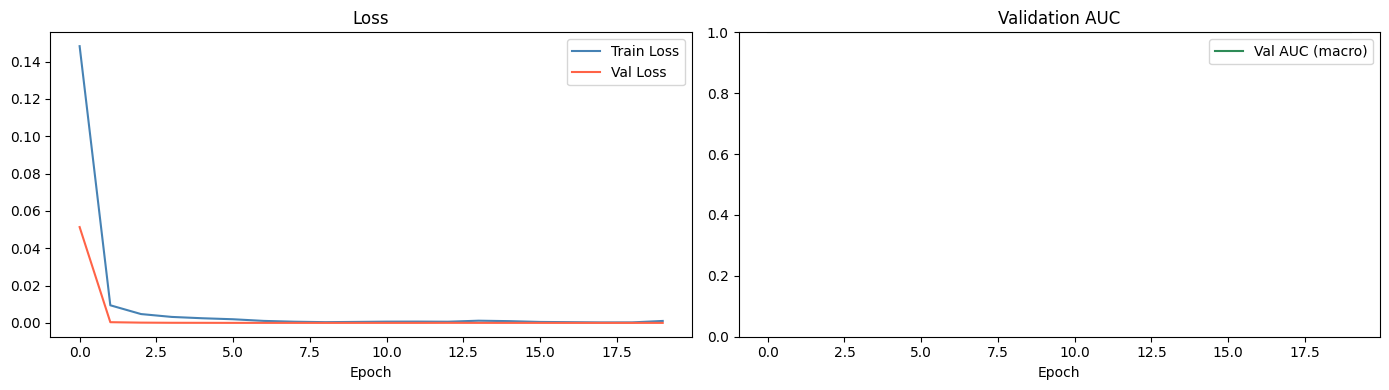

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['val_auc'], label='Val AUC (macro)', color='seagreen')
axes[1].set_title('Validation AUC'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim([0, 1]); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation — Precision-Recall Curves (per CWE group)
The paper uses PR curves as the primary metric due to class imbalance.

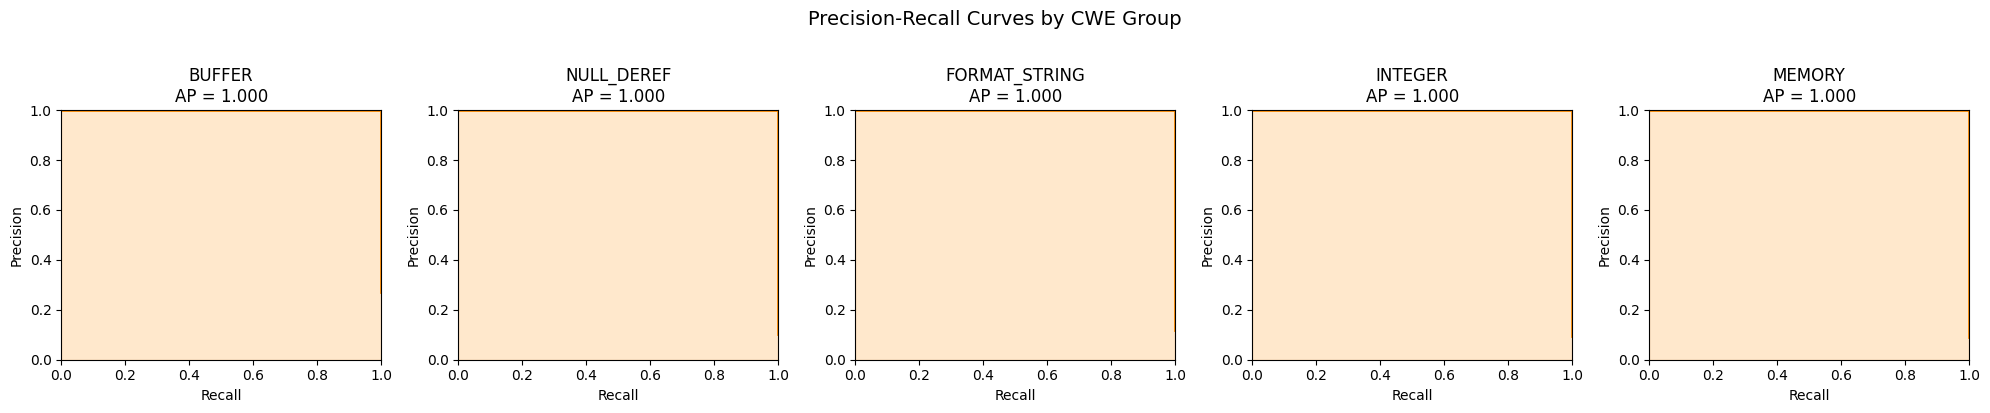

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load('best_vuln_model.pt', map_location=device))
_, test_preds, test_labels = run_epoch(test_loader, train=False)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))

for i, label_name in enumerate(LABEL_NAMES):
    ax = axes[i]
    if test_labels[:, i].sum() == 0:
        ax.set_title(f'{label_name}\n(no positives)')
        continue

    precision, recall, _ = precision_recall_curve(test_labels[:, i], test_preds[:, i])
    ap = average_precision_score(test_labels[:, i], test_preds[:, i])

    ax.step(recall, precision, where='post', color='darkorange', lw=2)
    ax.fill_between(recall, precision, alpha=0.2, color='darkorange', step='post')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{label_name}\nAP = {ap:.3f}')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

plt.suptitle('Precision-Recall Curves by CWE Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Classification Report at threshold 0.5 ──
binary_preds = (test_preds >= 0.5).astype(int)

print('Classification Report (threshold=0.5)\n')
print(classification_report(
    test_labels, binary_preds,
    target_names=LABEL_NAMES,
    zero_division=0
))

Classification Report (threshold=0.5)

               precision    recall  f1-score   support

       BUFFER       1.00      1.00      1.00        81
   NULL_DEREF       1.00      1.00      1.00        31
FORMAT_STRING       1.00      1.00      1.00        36
      INTEGER       1.00      1.00      1.00        29
       MEMORY       1.00      1.00      1.00        27

    micro avg       1.00      1.00      1.00       204
    macro avg       1.00      1.00      1.00       204
 weighted avg       1.00      1.00      1.00       204
  samples avg       0.68      0.68      0.68       204



## 10. Inference on New Code


In [ ]:
def predict_vulnerabilities(source_code: str, threshold: float = 0.4):
    """
    Predict vulnerability categories for a C function.
    Returns a dict of {CWE_group: probability}
    """
    model.eval()
    x = encode_function(source_code, MAX_LEN)
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)  # (1, max_len, 8)

    with torch.no_grad():
        probs = model(x_tensor).squeeze().cpu().numpy()

    results = {}
    print('\n📋 Vulnerability Prediction Results')
    print('=' * 45)
    for name, prob in zip(LABEL_NAMES, probs):
        flag = '⚠️  FLAGGED' if prob >= threshold else '   clean'
        results[name] = float(prob)
        bar = '█' * int(prob * 20)
        print(f'{name:<15} {prob:.3f}  [{bar:<20}]  {flag}')
    print()
    return results


# ── Test 1: Dangerous function ──
dangerous_code = """
void process_input(char *user_input) {
    char local_buf[16];
    strcpy(local_buf, user_input);  // classic stack overflow
    printf(local_buf);              // format string vuln too
}
"""
predict_vulnerabilities(dangerous_code)

# ── Test 2: Safe function ──
safe_code = """
int safe_add(int a, int b) {
    if (b > 0 && a > INT_MAX - b) return -1;
    if (b < 0 && a < INT_MIN - b) return -1;
    return a + b;
}
"""
predict_vulnerabilities(safe_code)


📋 Vulnerability Prediction Results
BUFFER          1.000  [███████████████████ ]  ⚠️  FLAGGED
NULL_DEREF      0.000  [                    ]     clean
FORMAT_STRING   0.000  [                    ]     clean
INTEGER         0.000  [                    ]     clean
MEMORY          0.000  [                    ]     clean


📋 Vulnerability Prediction Results
BUFFER          0.000  [                    ]     clean
NULL_DEREF      0.000  [                    ]     clean
FORMAT_STRING   0.000  [                    ]     clean
INTEGER         0.000  [                    ]     clean
MEMORY          0.000  [                    ]     clean



{'BUFFER': 6.824307785535666e-10,
 'NULL_DEREF': 1.0551128859503933e-08,
 'FORMAT_STRING': 2.011936839352302e-09,
 'INTEGER': 3.304216011912331e-09,
 'MEMORY': 1.4448354734852842e-09}